<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

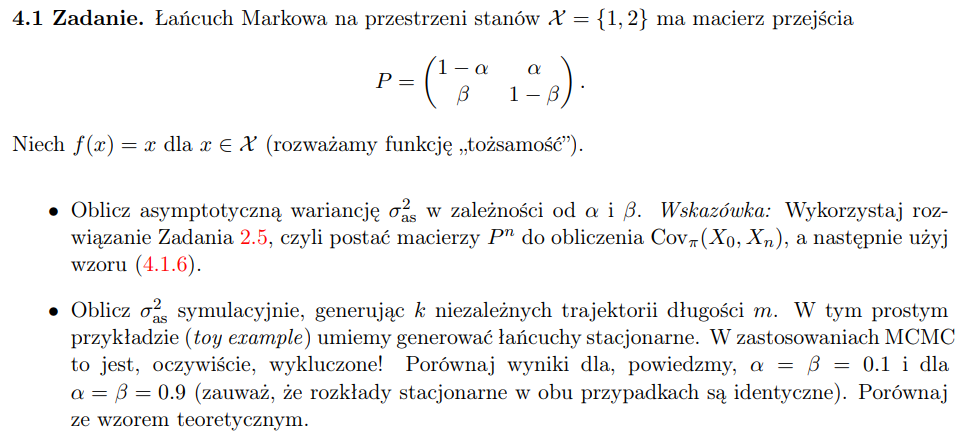

## Formula for $\sigma^2_{as}$
---
Let us recall that in Exercise 2.5, we compted the formulas for stationary distribution $\pi$ and transition matrix $P^n$:

$$
\pi = \left[ \frac{\beta}{\alpha+\beta}, \frac{\alpha}{\alpha+\beta} \right]
$$


$$
P^n = \frac{1}{\alpha + \beta} \begin{pmatrix} \beta + \alpha \lambda^n & \alpha - \alpha \lambda^n \\ \beta - \beta \lambda^n & \alpha + \beta \lambda^n \end{pmatrix},
$$

where $\lambda = 1 - \alpha -\beta$.


First, we compute the $(\mathbb{E}_\pi[X_0])^2$:

$$\mathbb{E}_\pi[X_0] = 1 \cdot \pi_1 + 2 \cdot \pi_2 = \frac{\beta + 2\alpha}{\alpha+\beta}$$

$$⇒ (\mathbb{E}_\pi[X_0])^2 = \frac{(\beta + 2\alpha)^2}{(\alpha+\beta)^2} = \frac{\beta^2 + 4\alpha\beta + 4\alpha^2}{(\alpha+\beta)^2}$$

Next, we can calculate the variance:

$$\mathbb{E}_\pi[X_0^2] = 1^2 \cdot \pi_1 + 2^2 \cdot \pi_2 = 1 \cdot \frac{\beta}{\alpha+\beta} + 4 \cdot \frac{\alpha}{\alpha+\beta} = \frac{\beta + 4\alpha}{\alpha+\beta}$$

$$\text{Var}_\pi(X_0) = \mathbb{E}_\pi[X_0^2] - (\mathbb{E}_\pi[X_0])^2$$

$$⇒ \text{Var}_\pi(X_0) = \frac{\alpha\beta}{(\alpha+\beta)^2}$$

Then, we may move to computing covariance:

$$\text{Cov}_\pi(X_0, X_n) = \mathbb{E}_\pi[X_0 X_n] - \mathbb{E}_\pi[X_0] \mathbb{E}_\pi[X_n]$$

$$\mathbb{E}_\pi[X_0 X_n] = 1\cdot 1\cdot \pi_1 P^n_{11} + 1\cdot 2\cdot \pi_1 P^n_{12} + 2\cdot 1\cdot \pi_2 P^n_{21} + 2\cdot 2\cdot \pi_2 P^n_{22},$$

which, after direct computations, equals to:

$$\mathbb{E}_\pi[X_0 X_n] = \frac{(\beta + 2\alpha)^2}{(\alpha+\beta)^2} + \lambda^n \frac{\alpha\beta}{(\alpha+\beta)^2}$$

Since Markov Chain starting from stationary distribution is stationary, we can compute $\mathbb{E}_\pi[X_0] \mathbb{E}_\pi[X_n]$ as $(\mathbb{E}_\pi[X_0])^2$. Now, we obtain formula for covariance:


$$\text{Cov}_\pi(X_0, X_n) = \frac{(\beta + 2\alpha)^2}{(\alpha+\beta)^2} + \lambda^n \frac{\alpha\beta}{(\alpha+\beta)^2} - \frac{\beta^2 + 4\alpha\beta + 4\alpha^2}{(\alpha+\beta)^2} = \lambda^n \frac{\alpha\beta}{(\alpha+\beta)^2} = \lambda^n \text{Var}_\pi f(X_0)$$


Finally, we are able to use the (4.1.6) formula:

$$\sigma^2_{as} = \text{Var}_\pi f(X_0) + 2 \sum_{n=1}^\infty \text{Cov}_\pi(f(X_0), f(X_n)) =  \text{Var}_\pi f(X_0) + 2 \sum_{n=1}^\infty \left[ \lambda^n \text{Var}_\pi f(X_0) \right] = \text{Var}_\pi f(X_0) \left( 1 + 2 \sum_{n=1}^\infty \lambda^n \right)  = 1 + 2 \frac{\lambda}{1-\lambda} = \frac{1+\lambda}{1-\lambda} =  \frac{\alpha\beta}{(\alpha+\beta)^2} \frac{2 - \alpha - \beta}{\alpha + \beta}$$

## Simulations
---

In [1]:
import numpy as np
import pandas as pd

In [3]:
def theoretical_asymptotic_variance(alpha, beta):
    return (alpha * beta) / (alpha + beta) ** 2 * (2 - alpha - beta) / (alpha + beta)

def simulate_mcmc_variance(alpha, beta, k=5000, m=1000):
    """
    Simulates the Markov chain to empirically estimate asymptotic variance.
    k: number of independent trajectories
    m: length of each trajectory
    """
    # stationary distributions
    pi_1 = beta / (alpha + beta)
    pi_2 = alpha / (alpha + beta)

    # array for the means
    trajectory_means = np.zeros(k)


    for i in range(k):
        # initial state
        current_state = np.random.choice([1, 2], p=[pi_1, pi_2])
        path_sum = 0

        for _ in range(m):
            path_sum += current_state
            # jump logic
            if current_state == 1:
                current_state = np.random.choice([1, 2], p=[1-alpha, alpha])
            else:
                current_state = np.random.choice([1, 2], p=[beta, 1-beta])

        # saving the mean of a trajectory
        trajectory_means[i] = path_sum / m

    # empirical asymptotic variance = m * var(means)
    empirical_asymptotic_variacne = m * np.var(trajectory_means, ddof=1)

    return empirical_asymptotic_variacne

# simulation
scenarios = [
    {"Name": "alpha = 0.1, beta = 0.1", "alpha": 0.1, "beta": 0.1},
    {"Name": "alpha = 0.9, beta = 0.9", "alpha": 0.9, "beta": 0.9}
]

results = []
for s in scenarios:
    a, b = s["alpha"], s["beta"]
    theo_var = theoretical_asymptotic_variance(a, b)
    emp_var = simulate_mcmc_variance(a, b)

    results.append({
        "Case": s["Name"],
        "α": a,
        "β": b,
        "σ²_as (Theory)": f"{theo_var:.4f}",
        "σ²_as (Simulation)": f"{emp_var:.4f}"
    })

df = pd.DataFrame(results)
display(df)

,Case,α,β,σ²_as (Theory),σ²_as (Simulation)
0,"alpha = 0.1, beta = 0.1",0.1,0.1,2.2500,2.2422
1,"alpha = 0.9, beta = 0.9",0.9,0.9,0.0278,0.0279
